#### 0. Importar librerias

In [2]:
import pandas as pd
import sklearn
import missingno as mo
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree,_tree
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

#### 1. Cargar e inspeccionar los datos

In [3]:
df = pd.read_csv('Datos/Transformados/df_final_para_regresion.csv')

In [4]:
df.head()

,booked_at,checkin_time,checkout_time,lead_time,lenght_of_stay,checkin_month,checkin_day,adult_count,child_count,origin,...,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin,mes_checkin,cluster,cluster_0,cluster_1,cluster_2
0,2022-11-26 16:10:00,2023-01-01,2023-01-02 12:00:00,36,1,January,Sunday,1,0,channel_manager,...,30.0,98.0,23:59,27.0,Varias,1,2,0,0,1
1,2022-12-21 17:27:00,2023-01-01,2023-01-10 12:00:00,11,9,January,Sunday,1,0,channel_manager,...,30.0,98.0,23:59,27.0,Varias,1,2,0,0,1
2,2022-09-21 19:46:00,2023-01-01,2023-01-07 12:00:00,102,6,January,Sunday,2,4,channel_manager,...,30.0,98.0,23:59,27.0,Varias,1,2,0,0,1
3,2022-09-24 12:09:00,2023-01-01,2023-01-02 12:00:00,99,1,January,Sunday,2,2,channel_manager,...,30.0,98.0,23:59,27.0,Varias,1,2,0,0,1
4,2022-10-18 07:12:00,2023-01-01,2023-01-02 12:00:00,75,1,January,Sunday,4,0,channel_manager,...,30.0,98.0,23:59,27.0,Varias,1,2,0,0,1


In [5]:
df.columns

Index(['booked_at', 'checkin_time', 'checkout_time', 'lead_time',
       'lenght_of_stay', 'checkin_month', 'checkin_day', 'adult_count',
       'child_count', 'origin', 'travel_agency_name', 'requested_category',
       'requested_category_name', 'asset', 'asset_type', 'brand',
       'asset_opening_date', 'available_units', 'business_segment', 'rate',
       'rate_group_name', 'rate_type', 'completed_entry_forms_count',
       'all_entry_forms_completed', 'last_entry_form_completed_at',
       'returning_inhabitant', 'recurrence', 'libere_community',
       'bought_products', 'product_count', 'reservation_net_value',
       'total_adr', 'status', 'cancelled_at', 'cancellation_reason',
       'cancellation_lead_time', 'ciudad', 'mes_cancelacion',
       'estacion_cancelacion', 'mes_estancia', 'estacion_estancia',
       'mes_reserva', 'estacion_reserva', 'dia_semana_reserva',
       'dia_semana_reserva_nombre', 'dia_semana_cancelacion',
       'dia_semana_cancelacion_nombre', 'dia_sem

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52004 entries, 0 to 52003
Data columns (total 86 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   booked_at                       52004 non-null  object 
 1   checkin_time                    52004 non-null  object 
 2   checkout_time                   52004 non-null  object 
 3   lead_time                       52004 non-null  int64  
 4   lenght_of_stay                  52004 non-null  int64  
 5   checkin_month                   52004 non-null  object 
 6   checkin_day                     52004 non-null  object 
 7   adult_count                     52004 non-null  int64  
 8   child_count                     52004 non-null  int64  
 9   origin                          52004 non-null  object 
 10  travel_agency_name              52004 non-null  object 
 11  requested_category              52004 non-null  object 
 12  requested_category_name         

In [7]:
df.shape

(52004, 86)

#### 2. Seleccion de variables relevantes para modelado

In [8]:
# Criterio para la seleccion de variables para regresion:
#    1. Primero se seleccionan únicamente variables disponibles en el momento de la reserva y que, desde el punto de vista de negocio, puedan influir en la probabilidad de cancelación.
#    2. Después mirar la relacion entre cada una de ellas con el target:
#       - para las numericas con corr
#       - para las binarias media del target
#       - para las categoricas la tasa de cancelacion por grupo (si se acaba seleccionando pasar a dummies)
#    3. Entre las seleccionadas, eliminar las que tengan alta correlacion entre ellas

In [9]:
# Definir el target
df['target'] = (df['status'] == 'cancelled').astype(int)

df['target'].value_counts(normalize=True) # 76% no cancelan

target
0    0.764018
1    0.235982
Name: proportion, dtype: float64

In [10]:
# 1. Seleccion conceptual
vars_numericas = ['lead_time', 'lenght_of_stay', 
                  'adult_count', 'child_count',
                  'available_units', 'reservation_net_value', 
                  'total_adr', 'product_count', 
                  'recurrence', 'ratio_cancelacion_mes_estancia', 
                  'tmed', 'prec', 'sol']

vars_binarias = ['zona_roja','es_finde',
                 'es_festivo', 'cluster_1',
                 'cluster_2']

vars_categoricas = ['origin', 'business_segment',
                    'rate_type', 'requested_category', 
                    'asset_type', 'brand', 'ciudad']

In [11]:
#2. Analisis de relacion con el target

# 2.1 Numericas
corr_num = (
    df[vars_numericas + ['target']]
    .corr()['target']
    .sort_values(ascending=False)
    .drop('target'))

print(corr_num)


lead_time                         0.220967
lenght_of_stay                    0.131798
adult_count                       0.101525
reservation_net_value             0.086955
total_adr                         0.053947
ratio_cancelacion_mes_estancia    0.025349
prec                              0.013570
child_count                      -0.006512
available_units                  -0.012650
sol                              -0.020129
tmed                             -0.025851
recurrence                       -0.046127
product_count                    -0.135070
Name: target, dtype: float64


In [12]:
# Nos quedamos con |corr| >= 0.05 y 1, porque aun que sean correlaciones debiles, al tratarse de cancelaciones y de comportamiento humano,
# 0.10 ya es bastante y 0.05 puede ser útil combinado con otras variables
vars_numericas_filtradas = corr_num[corr_num.abs() >= 0.05].index.tolist()
print(vars_numericas_filtradas)

['lead_time', 'lenght_of_stay', 'adult_count', 'reservation_net_value', 'total_adr', 'product_count']


In [13]:
# Mirar si hay alta correlacion entre las numericas (para evitar multicolinealidad)
print(df[vars_numericas_filtradas].corr()) # Ninguna supera un valor critico (~0.7), asi que no eliminamos ninguna

                       lead_time  lenght_of_stay  adult_count  \
lead_time               1.000000        0.098732     0.220131   
lenght_of_stay          0.098732        1.000000    -0.030339   
adult_count             0.220131       -0.030339     1.000000   
reservation_net_value   0.176664        0.448822     0.330383   
total_adr               0.134558       -0.078498     0.526133   
product_count           0.105714        0.121244     0.032290   

                       reservation_net_value  total_adr  product_count  
lead_time                           0.176664   0.134558       0.105714  
lenght_of_stay                      0.448822  -0.078498       0.121244  
adult_count                         0.330383   0.526133       0.032290  
reservation_net_value               1.000000   0.626397       0.307983  
total_adr                           0.626397   1.000000       0.190920  
product_count                       0.307983   0.190920       1.000000  


In [14]:
# 2.2 Binarias
for var in vars_binarias:
    print(f'\n{var}')
    print(df.groupby(var)['target'].mean())


zona_roja
zona_roja
0    0.230250
1    0.249437
Name: target, dtype: float64

es_finde
es_finde
0    0.229869
1    0.251552
Name: target, dtype: float64

es_festivo
es_festivo
0    0.236251
1    0.227094
Name: target, dtype: float64

cluster_1
cluster_1
0    0.232667
1    0.241563
Name: target, dtype: float64

cluster_2
cluster_2
0    0.241056
1    0.228008
Name: target, dtype: float64


In [15]:
# Para las variables binarias un umbral razonable de diferencia puede ser mayor que 0.02
vars_binarias_filtradas = []

for var in vars_binarias:
    medias = df.groupby(var)['target'].mean()
    diff = abs(medias[1] - medias[0])
    if diff > 0.02:
        vars_binarias_filtradas.append(var)

print(vars_binarias_filtradas)

['es_finde']


In [16]:
# 2.3 Categoricas
for var in vars_categoricas:
    print(f'\n{var}')
    display(
        df.groupby(var)['target']
        .mean()
        .sort_values(ascending=False)
        .head(10))


origin


origin
email              0.420612
telephone          0.302963
in_person          0.301370
channel_manager    0.240168
direct_channel     0.136554
Name: target, dtype: float64


business_segment


business_segment
Travel Individual      0.474332
Business Individual    0.440613
Mid Stay               0.365385
Travel Group           0.342903
MICE Group             0.321063
MICE Individual        0.276471
Leisure Group          0.236181
Leisure Individual     0.219563
Business Group         0.149533
Name: target, dtype: float64


rate_type


...

asset_type
apartment     0.241563
aparthotel    0.240264
hostel        0.228008
Name: target, dtype: float64


brand


brand
koisi     0.259020
libere    0.230342
Name: target, dtype: float64


ciudad


ciudad
Valencia    0.285312
Granada     0.271475
Donosti     0.259020
Bilbao      0.253384
Vitoria     0.240264
Madrid      0.227432
Pamplona    0.219519
Málaga      0.217810
Córdoba     0.196279
Name: target, dtype: float64

In [17]:
vars_categoricas_filtradas = []

for var in vars_categoricas:
    medias = df.groupby(var)['target'].mean()
    diff = medias.max() - medias.min()
    if diff >= 0.03:
        vars_categoricas_filtradas.append(var)

print(vars_categoricas_filtradas) 


['origin', 'business_segment', 'rate_type', 'requested_category', 'ciudad']


In [18]:
# Crear el df para modelado con las variables seleccionadas
df_modelo = df[vars_numericas_filtradas + vars_binarias_filtradas + vars_categoricas_filtradas + ['target']]

df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52004 entries, 0 to 52003
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   lead_time              52004 non-null  int64  
 1   lenght_of_stay         52004 non-null  int64  
 2   adult_count            52004 non-null  int64  
 3   reservation_net_value  52004 non-null  float64
 4   total_adr              52004 non-null  float64
 5   product_count          52004 non-null  int64  
 6   es_finde               52004 non-null  int64  
 7   origin                 52004 non-null  object 
 8   business_segment       52004 non-null  object 
 9   rate_type              52004 non-null  object 
 10  requested_category     52004 non-null  object 
 11  ciudad                 52004 non-null  object 
 12  target                 52004 non-null  int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 5.2+ MB


#### 3. Separar train / test

In [19]:
# Primero separar X (variables explicativas) e Y (target)
X = df_modelo.drop(columns='target')
Y = df_modelo['target']

# Separar train y test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y) # stratify=Y asegura que train y test tengan la misma propocion de clases que el df original, importante porque el target esta desbalanceado (76% no cancelan)

# Separar las variables por numericas binarias y categoricas para preprocesar cada una de una manera
# Numéricas
X_train_num = X_train[vars_numericas_filtradas]
X_test_num = X_test[vars_numericas_filtradas]

# Binarias (ya son 0/1)
X_train_bin = X_train[vars_binarias_filtradas]
X_test_bin = X_test[vars_binarias_filtradas]

In [20]:
# Ahora dummificar las variables categoricas seleccionadas
ohe = OneHotEncoder(
    drop='first',
    handle_unknown='ignore')

# Fit SOLO con train
X_train_cat = ohe.fit_transform(X_train[vars_categoricas_filtradas]).toarray()
X_test_cat = ohe.transform(X_test[vars_categoricas_filtradas]).toarray()

# Convertir a data frame
cat_cols = ohe.get_feature_names_out(vars_categoricas_filtradas)

X_train_cat = pd.DataFrame(X_train_cat, columns=cat_cols, index=X_train.index)
X_test_cat = pd.DataFrame(X_test_cat, columns=cat_cols, index=X_test.index)

In [21]:
# Concatenar todas las variables
X_train = pd.concat(
    [X_train_num, X_train_bin, X_train_cat],
    axis=1)

X_test = pd.concat(
    [X_test_num, X_test_bin, X_test_cat],
    axis=1)

#### 4. Escalar las variables numéricas continuas

In [22]:
# Escalar solo numéricas
scaler = MinMaxScaler()

X_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_train[vars_numericas_filtradas]),
    columns=vars_numericas_filtradas,
    index=X_train.index)
X_test_num_scaled = pd.DataFrame(
    scaler.transform(X_test[vars_numericas_filtradas]),
    columns=vars_numericas_filtradas,
    index=X_test.index)

# Variables no numéricas: binarias + todas las dummies restantes
vars_no_num = [c for c in X_train.columns if c not in vars_numericas_filtradas]

X_train_scaled = pd.concat([X_train_num_scaled, X_train[vars_no_num]], axis=1)
X_test_scaled = pd.concat([X_test_num_scaled, X_test[vars_no_num]], axis=1)

X_train_scaled.head()

,lead_time,lenght_of_stay,adult_count,reservation_net_value,total_adr,product_count,es_finde,origin_direct_channel,origin_email,origin_in_person,...,requested_category_Two bedroom apartment,requested_category_Two bedroom apartment superior,ciudad_Córdoba,ciudad_Donosti,ciudad_Granada,ciudad_Madrid,ciudad_Málaga,ciudad_Pamplona,ciudad_Valencia,ciudad_Vitoria
41843,0.012236,0.000000,0.2,0.105145,0.106321,0.033333,0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50805,0.007786,0.038462,0.2,0.431540,0.109092,0.133333,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1397,0.004449,0.000000,0.1,0.049357,0.049909,0.000000,1,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
24592,0.293660,0.000000,0.6,0.119677,0.121015,0.000000,0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18914,0.014461,0.000000,0.1,0.068160,0.068922,0.000000,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [23]:
# Aplicar PCA

# PCA para explicar el 90–95% de la varianza
# SOLO A LAS VARIABLES NÚMERCIAS
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_num_scaled)
X_test_pca = pca.transform(X_test_num_scaled)

print("Componentes PCA:", pca.n_components_)
print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())

# Convertir a df
pca_cols = [f'PC{i+1}' for i in range(pca.n_components_)]

X_train_pca = pd.DataFrame(
    X_train_pca,
    columns=pca_cols,
    index=X_train.index)

X_test_pca = pd.DataFrame(
    X_test_pca,
    columns=pca_cols,
    index=X_test.index)

# Concatenar PCA + binarias + dummies
X_train_pca_final = pd.concat(
    [X_train_pca, X_train[vars_no_num]],
    axis=1
)

X_test_pca_final = pd.concat(
    [X_test_pca, X_test[vars_no_num]],
    axis=1
)

X_train_pca_final.head()

Componentes PCA: 4
Varianza explicada acumulada: 0.9636169061456472


,PC1,PC2,PC3,PC4,es_finde,origin_direct_channel,origin_email,origin_in_person,origin_telephone,business_segment_Business Individual,...,requested_category_Two bedroom apartment,requested_category_Two bedroom apartment superior,ciudad_Córdoba,ciudad_Donosti,ciudad_Granada,ciudad_Madrid,ciudad_Málaga,ciudad_Pamplona,ciudad_Valencia,ciudad_Vitoria
41843,-0.090010,0.026132,-0.023270,0.025407,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50805,0.211860,-0.108047,-0.009776,-0.021031,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1397,-0.191730,-0.048958,-0.016842,0.001182,1,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
24592,0.080767,0.406123,0.230993,0.021328,0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18914,-0.169424,-0.053001,-0.013231,0.017040,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [24]:
# Aplicar SMOTE  con PCAa train
smote = SMOTE(random_state=42)
X_train_pca_res, Y_train_pca_res = smote.fit_resample(X_train_pca_final, Y_train)

c:\conda_envs\reto06_VerdeOscuro\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


#### 5. Entrenar modelo de Regresión Logística

              precision    recall  f1-score   support

           0     0.8677    0.6994    0.7745     11920
           1     0.4022    0.6548    0.4983      3682

    accuracy                         0.6889     15602
   macro avg     0.6350    0.6771    0.6364     15602
weighted avg     0.7579    0.6889    0.7093     15602



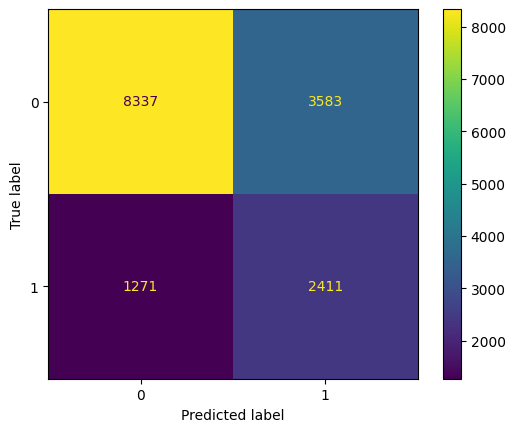

In [25]:
# Modelo
modelo_reg_log = LogisticRegression(max_iter=10000, class_weight='balanced', l1_ratio=0.5, solver='saga')
modelo_reg_log.fit(X_train_pca_final, Y_train)

#Predicciones
y_prob = modelo_reg_log.predict_proba(X_test_pca_final)[:,1]
y_pred = (y_prob >= 0.53).astype(int)

# Metricas
print(classification_report(Y_test, y_pred, digits=4))

# Matriz de confusion
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [26]:
# Ver cual es el mejor valor de probabilidad y ajustar
thresholds = np.arange(0.1, 0.9, 0.01)
best_thresh, best_f1 = 0.5, 0

for t in thresholds:
    y_pred_thresh = (y_prob >= t).astype(int)
    f1 = f1_score(Y_test, y_pred_thresh)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Mejor threshold:", best_thresh, "con F1:", best_f1)

Mejor threshold: 0.5099999999999998 con F1: 0.5018032946680963


In [27]:
def evaluar_modelo(nombre, y_test, y_pred, y_prob, resultados):
    report = classification_report(y_test, y_pred, output_dict=True)

    resultados.append({
        'Modelo': nombre,
        'F1_canceladas': report['1']['f1-score'],
        'Recall_canceladas': report['1']['recall'],
        'Precision_canceladas': report['1']['precision'],
        'ROC_AUC': roc_auc_score(y_test, y_prob)
    })

In [28]:
resultados = []

evaluar_modelo(
    nombre='Regresión logística',
    y_test=Y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    resultados=resultados)

              precision    recall  f1-score   support

           0     0.8677    0.6994    0.7745     11920
           1     0.4022    0.6548    0.4983      3682

    accuracy                         0.6889     15602
   macro avg     0.6350    0.6771    0.6364     15602
weighted avg     0.7579    0.6889    0.7093     15602



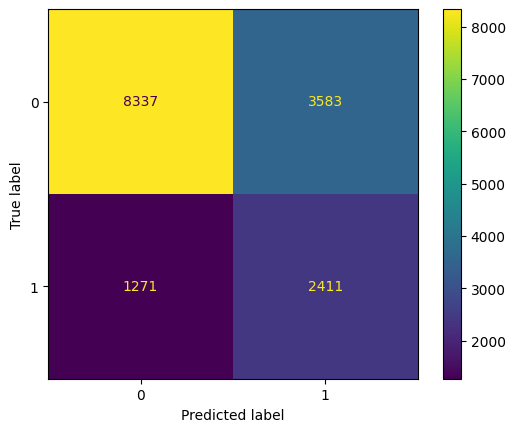

In [29]:
# Regresión Logística con SMOTE

# Modelo
modelo_reg_log_res = LogisticRegression(max_iter=10000, class_weight='balanced', l1_ratio=0.5, solver='saga')
modelo_reg_log_res.fit(X_train_pca_res, Y_train_pca_res)

#Predicciones
y_prob = modelo_reg_log.predict_proba(X_test_pca_final)[:,1]
y_pred = (y_prob >= 0.53).astype(int)

# Metricas
print(classification_report(Y_test, y_pred, digits=4))

# Matriz de confusion
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [30]:
evaluar_modelo(
    nombre='Regresión logística SMOTE',
    y_test=Y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    resultados=resultados)

#### 6. Entrenar modelo SVM

              precision    recall  f1-score   support

           0     0.8824    0.6150    0.7248     11920
           1     0.3709    0.7347    0.4929      3682

    accuracy                         0.6433     15602
   macro avg     0.6266    0.6748    0.6089     15602
weighted avg     0.7617    0.6433    0.6701     15602



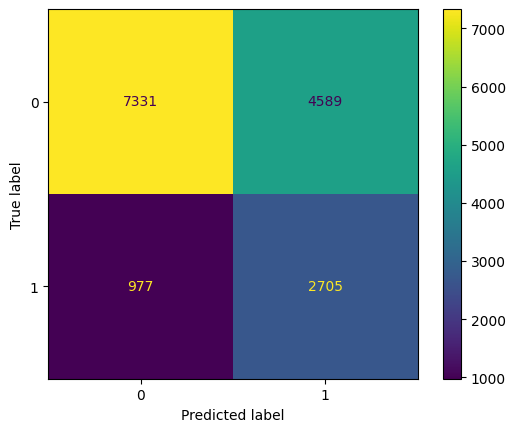

In [31]:
# Modelo 
svm = SVC(kernel='rbf', 
          C=1,
          gamma='scale',
          class_weight='balanced',
          probability=True,
          random_state=42)

# Entrenarlo
svm.fit(X_train_pca_final, Y_train)

# Predicciones
y_prob = svm.predict_proba(X_test_pca_final)[:, 1]
y_pred = svm.predict(X_test_pca_final)

# Métricas
print(classification_report(Y_test, y_pred, digits=4))

# Matriz de confusion
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [32]:
evaluar_modelo(
    nombre='SVM',
    y_test=Y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    resultados=resultados)

              precision    recall  f1-score   support

           0     0.8817    0.6213    0.7289     11920
           1     0.3732    0.7300    0.4939      3682

    accuracy                         0.6470     15602
   macro avg     0.6274    0.6757    0.6114     15602
weighted avg     0.7617    0.6470    0.6735     15602



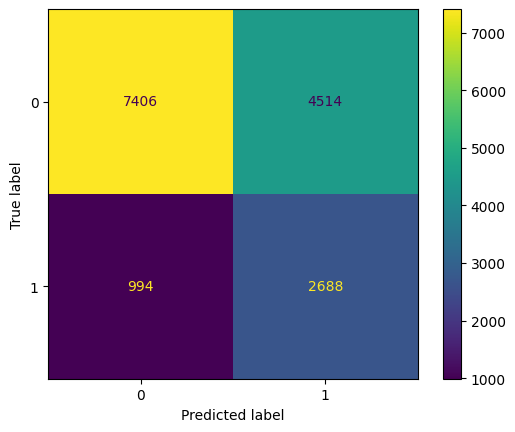

In [33]:
# Probar con SMOTE

# Modelo 
svm = SVC(kernel='rbf', 
          C=1,
          gamma='scale',
          class_weight='balanced',
          probability=True,
          random_state=42)

# Entrenarlo
svm.fit(X_train_pca_res, Y_train_pca_res)

# Predicciones
y_prob = svm.predict_proba(X_test_pca_final)[:, 1]
y_pred = svm.predict(X_test_pca_final)

# Métricas
print(classification_report(Y_test, y_pred, digits=4))

# Matriz de confusion
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [34]:
evaluar_modelo(
    nombre='SVM SMOTE',
    y_test=Y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    resultados=resultados)

##### 7. Entrenar modelo Naive

              precision    recall  f1-score   support

           0     0.7876    0.8903    0.8358     11920
           1     0.3853    0.2227    0.2823      3682

    accuracy                         0.7327     15602
   macro avg     0.5865    0.5565    0.5590     15602
weighted avg     0.6927    0.7327    0.7052     15602



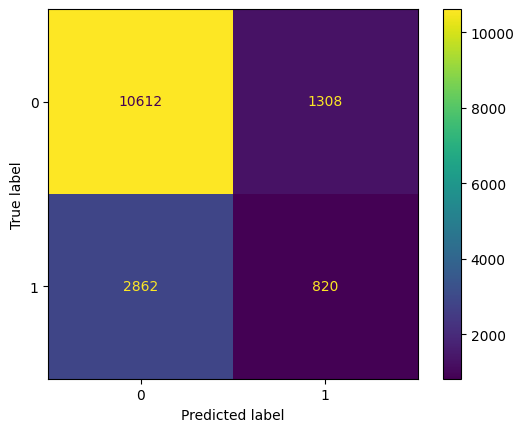

In [35]:
# Modelo
nb_model = GaussianNB()
nb_model.fit(X_train_pca_final, Y_train)

# Predicciones
y_pred = nb_model.predict(X_test_pca_final)
y_prob = nb_model.predict_proba(X_test_pca_final)[:, 1]

# Métricas
print(classification_report(Y_test, y_pred, digits=4))

# Matriz de confusion
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [36]:
evaluar_modelo(
    nombre='Naive Bayes',
    y_test=Y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    resultados=resultados)

              precision    recall  f1-score   support

           0     0.7876    0.8903    0.8358     11920
           1     0.3853    0.2227    0.2823      3682

    accuracy                         0.7327     15602
   macro avg     0.5865    0.5565    0.5590     15602
weighted avg     0.6927    0.7327    0.7052     15602



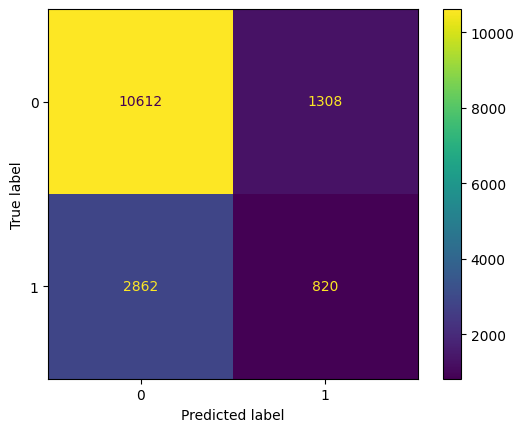

In [37]:
# Probar Niave Bayes con SMOTE

# Modelo
nb_model_res = GaussianNB()
nb_model_res.fit(X_train_pca_res, Y_train_pca_res)

# Predicciones
y_pred = nb_model.predict(X_test_pca_final)
y_prob = nb_model.predict_proba(X_test_pca_final)[:, 1]

# Métricas
print(classification_report(Y_test, y_pred, digits=4))

# Matriz de confusion
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [38]:
evaluar_modelo(
    nombre='Naive Bayes SMOTE',
    y_test=Y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    resultados=resultados)

##### 8. Entrenar modelo Random Forest

              precision    recall  f1-score   support

           0     0.8399    0.9355    0.8851     11920
           1     0.6694    0.4229    0.5183      3682

    accuracy                         0.8145     15602
   macro avg     0.7547    0.6792    0.7017     15602
weighted avg     0.7997    0.8145    0.7986     15602



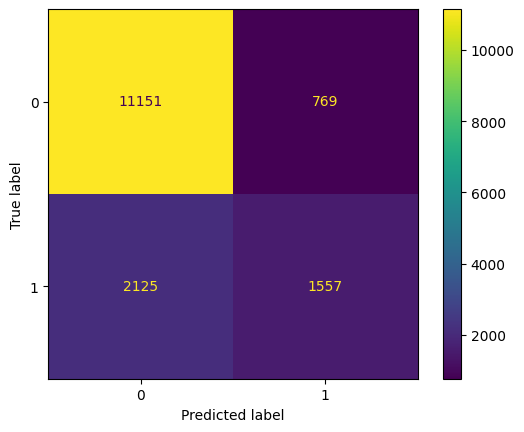

In [39]:
# Crear el modelo Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,      # Número de árboles
    max_depth=None,        # Profundidad máxima de los árboles (None = expandir hasta hojas puras)
    class_weight='balanced', # Ajusta pesos por desbalance de clases
    random_state=42,
    n_jobs=-1,              # Usar todos los núcleos de la CPU
    max_features='log2',
    min_samples_leaf=1
)

# Entrenar el modelo
rf_model.fit(X_train_pca_final, Y_train)

# Predicciones
y_pred = rf_model.predict(X_test_pca_final)
y_prob = rf_model.predict_proba(X_test_pca_final)[:, 1]

# Métricas
print(classification_report(Y_test, y_pred, digits=4))

# Matriz de confusion
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [40]:
evaluar_modelo(
    nombre='Random Forest',
    y_test=Y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    resultados=resultados)

              precision    recall  f1-score   support

           0     0.8786    0.8146    0.8454     11920
           1     0.5143    0.6355    0.5685      3682

    accuracy                         0.7723     15602
   macro avg     0.6964    0.7251    0.7069     15602
weighted avg     0.7926    0.7723    0.7800     15602



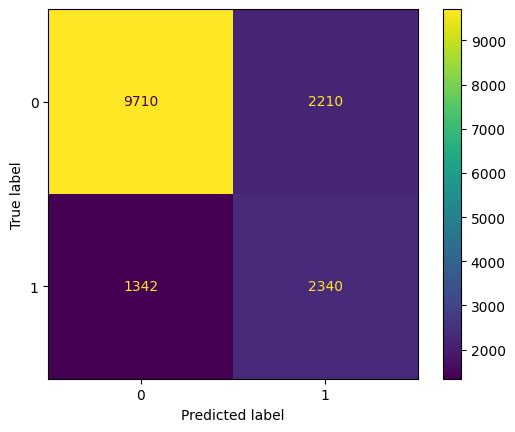

In [41]:
# Random Forest con SMOTE

# Modelo
rf_model = RandomForestClassifier(
    n_estimators=300,      
    max_depth=None,        
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1              
)

# Entrenar el modelo
rf_model.fit(X_train_pca_res, Y_train_pca_res)

# Predicciones
y_pred = rf_model.predict(X_test_pca_final)
y_prob = rf_model.predict_proba(X_test_pca_final)[:, 1]

# Métricas
print(classification_report(Y_test, y_pred, digits=4))

# Matriz de confusion
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [42]:
evaluar_modelo(
    nombre='Random Forest SMOTE',
    y_test=Y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    resultados=resultados)

##### 9. Entrenar modelo Arbol de Decisión

ROC AUC: 0.732557706363991
              precision    recall  f1-score   support

           0     0.8623    0.7487    0.8015     11920
           1     0.4297    0.6130    0.5053      3682

    accuracy                         0.7167     15602
   macro avg     0.6460    0.6809    0.6534     15602
weighted avg     0.7602    0.7167    0.7316     15602



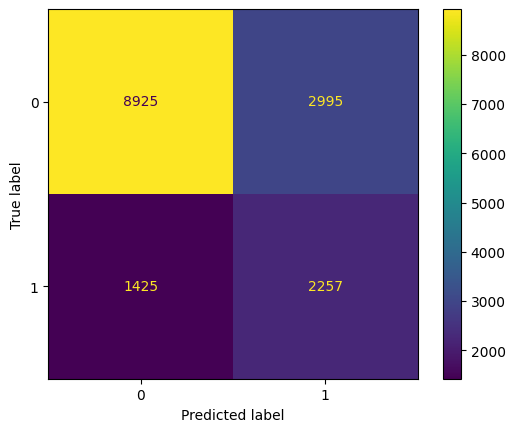

In [43]:
# Modelo
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=4,
    min_samples_leaf=100,
    class_weight='balanced')

# Entrenar modelo
dt.fit(X_train_pca_final, Y_train)

# Predicciones
y_pred = dt.predict(X_test_pca_final)
y_proba = dt.predict_proba(X_test_pca_final)[:, 1]

# Metricas
f1 = f1_score(Y_test, y_pred, pos_label=1)
roc_auc = roc_auc_score(Y_test, y_proba)

print("ROC AUC:", roc_auc)

print(classification_report(Y_test, y_pred, digits=4))

# Matriz de confusion
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [44]:
evaluar_modelo(
    nombre='Decision Tree',
    y_test=Y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    resultados=resultados)

F1-score (canceladas): 0.5154946364719905
ROC AUC: 0.7430250534069244
              precision    recall  f1-score   support

           0     0.8821    0.6820    0.7692     11920
           1     0.4064    0.7048    0.5155      3682

    accuracy                         0.6873     15602
   macro avg     0.6442    0.6934    0.6424     15602
weighted avg     0.7698    0.6873    0.7093     15602



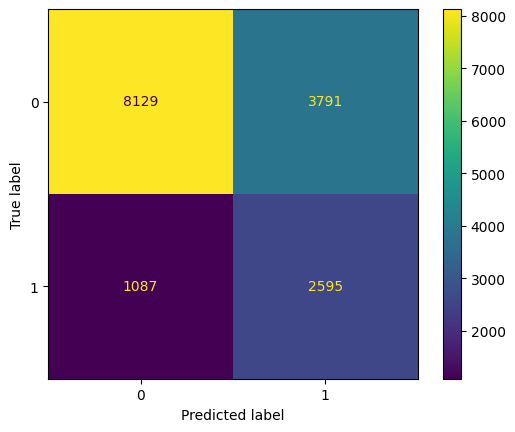

In [45]:
# Decision Tree con SMOTE

# Modelo
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    min_samples_leaf=50,
    class_weight='balanced')

# Entrenar modelo
dt.fit(X_train_pca_res, Y_train_pca_res)

# Predicciones
y_pred = dt.predict(X_test_pca_final)
y_proba = dt.predict_proba(X_test_pca_final)[:, 1]

# Metricas
f1 = f1_score(Y_test, y_pred, pos_label=1)
roc_auc = roc_auc_score(Y_test, y_proba)

print("F1-score (canceladas):", f1)
print("ROC AUC:", roc_auc)

print(classification_report(Y_test, y_pred, digits=4))

# Matriz de confusion
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [46]:
evaluar_modelo(
    nombre='Decision Tree SMOTE',
    y_test=Y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    resultados=resultados)

##### 10. Comparar modelos

In [ ]:
df_resultados = pd.DataFrame(resultados)
df_resultados_final = df_resultados.sort_values(by='F1_canceladas', ascending=False).round(4)
df_resultados_final # pca

,Modelo,F1_canceladas,Recall_canceladas,Precision_canceladas,ROC_AUC
7,Random Forest SMOTE,0.5685,0.6355,0.5143,0.8095
6,Random Forest,0.5183,0.4229,0.6694,0.8104
9,Decision Tree SMOTE,0.5155,0.7048,0.4064,0.8095
8,Decision Tree,0.5053,0.6130,0.4297,0.8095
1,Regresión logística SMOTE,0.4983,0.6548,0.4022,0.7321
0,Regresión logística,0.4983,0.6548,0.4022,0.7321
3,SVM SMOTE,0.4939,0.7300,0.3732,0.7446
2,SVM,0.4929,0.7347,0.3709,0.7454
5,Naive Bayes SMOTE,0.2823,0.2227,0.3853,0.6784
4,Naive Bayes,0.2823,0.2227,0.3853,0.6784
